## Inteligentne systemy wspomagania decyzji - Laboratorium 2

| Alternatywa | Cena (PLN) | Pojemność skokowa (cm³) | Moc (KM) | Średnie spalanie (l/100km) | Bezpieczeństwo Euro NCAP (%) |
|---|---|---|---|---|---|
| Volkswagen Golf 1.5 TSI | 135000 | 1498 | 150 | 5.8 | 92 |
| Toyota Corolla 1.8 Hybrid | 148000 | 1798 | 140 | 4.5 | 94 |
| Mazda3 2.0 Skyactiv | 128000 | 1998 | 122 | 6.2 | 91 |
| Skoda Octavia 1.5 TSI | 132000 | 1498 | 150 | 5.9 | 93 |
| Kia Ceed 1.6 T-GDI | 125000 | 1598 | 160 | 6.5 | 89 |
| Hyundai i30 1.5 T-GDI | 122000 | 1482 | 160 | 6.3 | 90 |
| Ford Focus 1.0 EcoBoost | 115000 | 999 | 125 | 5.4 | 87 |
| Peugeot 308 1.2 PureTech | 138000 | 1199 | 130 | 5.7 | 91 |
| Honda Civic 1.5 VTEC Turbo | 142000 | 1498 | 182 | 6.8 | 92 |
| Renault Megane E-Tech | 165000 | 1598 | 200 | 4.8 | 95 |

**Typy kryteriów:**

- Cena (PLN): KOSZT 
- Pojemność skokowa (cm³): KOSZT
- Moc (KM): ZYSK 
- Średnie spalanie (l/100km): KOSZT 
- Bezpieczeństwo Euro NCAP (%): ZYSK 

In [19]:
from pymcdm.weights.subjective import AHP, RANCOM
import numpy as np
import matplotlib.pyplot as plt

D = np.array([
    [135000, 1498, 150, 5.8, 92],
    [148000, 1798, 140, 4.5, 94],
    [128000, 1998, 122, 6.2, 91],
    [132000, 1498, 150, 5.9, 93],
    [125000, 1598, 160, 6.5, 89],
    [122000, 1482, 160, 6.3, 90],
    [115000, 999, 125, 5.4, 87],
    [138000, 1199, 130, 5.7, 91],
    [142000, 1498, 182, 6.8, 92],
    [165000, 1598, 200, 4.8, 95]
], dtype=float)
types = np.array([-1, 1, 1, -1, 1])  

Wagi my_rancom: [0.36 0.12 0.04 0.2  0.28]


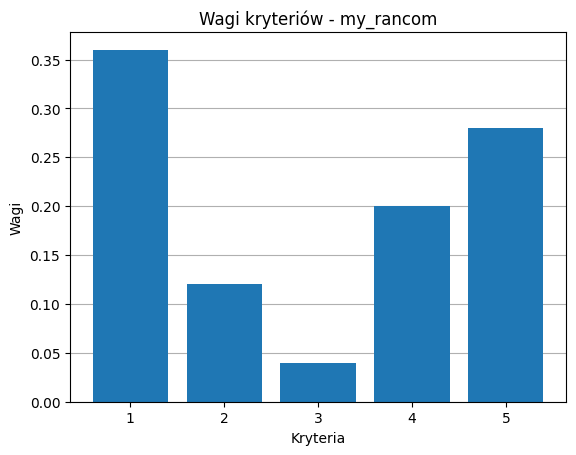

In [20]:
def my_rancom(X):
    n = len(X)
    mac = np.zeros((n,n), dtype=float)

    for i in range(n):
        for j in range(n):
            if X[i] < X[j]:
                mac[i][j] = 1.0
            elif X[i] == X[j]:
                mac[i][j] = 0.5
            else:
                mac[i][j] = 0.0

    scw = mac.sum(axis=1)
    w = scw / scw.sum()
   
    return w


ranking = [1,4,5,3,2]
weights = my_rancom(ranking)
print("Wagi my_rancom:", weights)

plt.bar(range(1, len(weights)+1), weights)
plt.xlabel('Kryteria')
plt.ylabel('Wagi')
plt.title('Wagi kryteriów - my_rancom')
plt.xticks(range(1, len(weights)+1))
plt.grid(axis='y')
plt.rcParams['axes.axisbelow'] = True
plt.show()


In [21]:
ahp = AHP(ranking)
weights_ahp = ahp()
print("Wagi AHP :", weights_ahp)

Wagi AHP : [0.44328562 0.11235943 0.10798204 0.13913235 0.19724056]


Wagi RANCOM : [0.36 0.12 0.04 0.2  0.28]


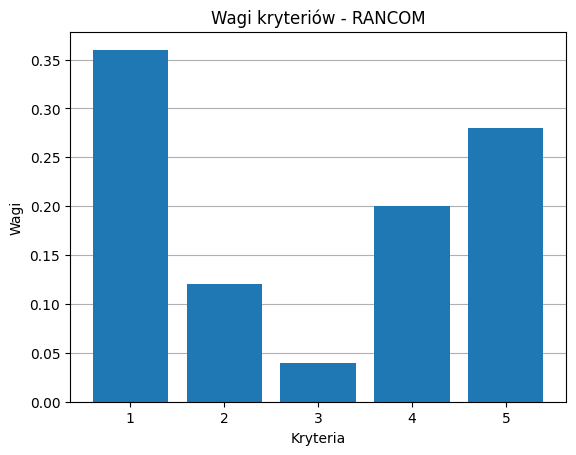

In [22]:
rancom = RANCOM(ranking)
weights_rancom = rancom()
print("Wagi RANCOM :", weights_rancom)
plt.bar(range(1, len(weights_rancom)+1), weights_rancom)
plt.xlabel('Kryteria')
plt.ylabel('Wagi')
plt.title('Wagi kryteriów - RANCOM')
plt.xticks(range(1, len(weights_rancom)+1))
plt.grid(axis='y')
plt.show()

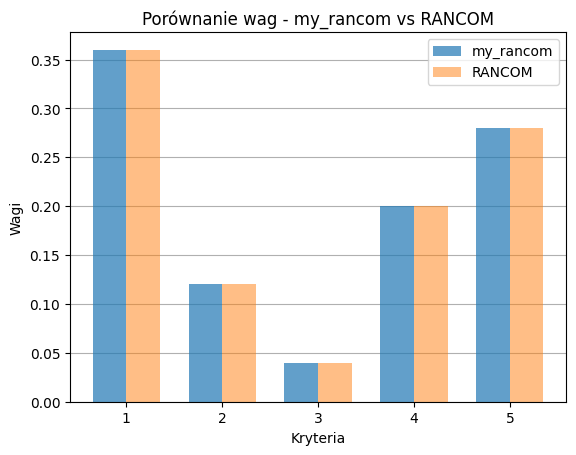

In [23]:
n = len(weights)
idx = np.arange(1, n+1)  
width = 0.35                  
plt.bar(idx - width/2, weights, width=width, alpha=0.7, label='my_rancom')
plt.bar(idx+ width/2, weights_rancom, width=width, alpha=0.5, label='RANCOM')
plt.xlabel('Kryteria')
plt.ylabel('Wagi')
plt.title('Porównanie wag - my_rancom vs RANCOM')
plt.xticks(idx)              
plt.legend()
plt.grid(axis='y')
plt.show()

In [25]:
# Problem 1 -> e-book(Cena, Przekątna, Pamięć, Czas pracy) 
ebook_matrix = np.array([
    [400, 6.0, 16,  6],   # Kindle 11
    [650, 6.8,  8, 10],   # Kindle Paperwhite 5
    [700, 6.0, 16,  6],   # Kobo Clara BW / 2e
    [600, 6.0, 16,  6],   # PocketBook Verse Pro
    [900, 7.0, 32,  6],   # Kobo Libra 2
], dtype=float)
ebook_types = np.array([-1, 1, 1, 1])
ebook_ranking = [1, 4, 2, 3]

In [26]:
# Problem 2 -> telefon android(Cena, Ram, Pamięć, Pojemność baterii, Aparat, Odświeżanie)
phone_matrix = np.array([
    [1900,  8, 256, 5000, 50, 120],  # Galaxy A56 5G
    [2200, 12, 256, 5000, 64, 120],  # POCO F7 Pro
    [2400,  8, 128, 4600, 64,  90],  # Google Pixel 10a
    [2600, 12, 256, 5000, 50, 120],  # Xiaomi 17
    [2600,  8, 256, 4500, 50, 120],  # Galaxy S25 FE
], dtype=float)
phone_types = np.array([-1, 1, 1, 1, 1, 1])
phone_ranking = [1, 4, 2, 3, 5, 6]

In [27]:
# Problem 3 -> laptop(Cena, RAM, SSD, Przekątna, Rozdzielczość, Waga, Czas pracy, Wydajność)
laptop_matrix = np.array([
    [3800, 16,  512, 16.0, 2560, 1.8, 8, 7],  # Acer Aspire 16 AI
    [4400, 16,  512, 17.3, 1920, 2.3, 6, 6],  # Lenovo V17
    [4500, 16,  512, 14.0, 2880, 1.4, 9, 7],  # HP OmniBook X Flip AI
    [3000, 16,  512, 15.6, 1920, 1.7, 7, 6],  # Dell Inspiron 3530
    [9000, 32, 1024, 14.0, 2880, 1.7, 7, 9],  # ASUS ROG Zephyrus G14
], dtype=float)
laptop_types = np.array([-1, 1, 1, 1, 1, 1, 1, 1])
laptop_ranking = [1, 6, 7, 8 ,2, 3, 4, 5]

Problem 1 - e-book
Wagi AHP: [0.48144852 0.13073309 0.21998235 0.16783605]
CR AHP: 0.017120384299763772


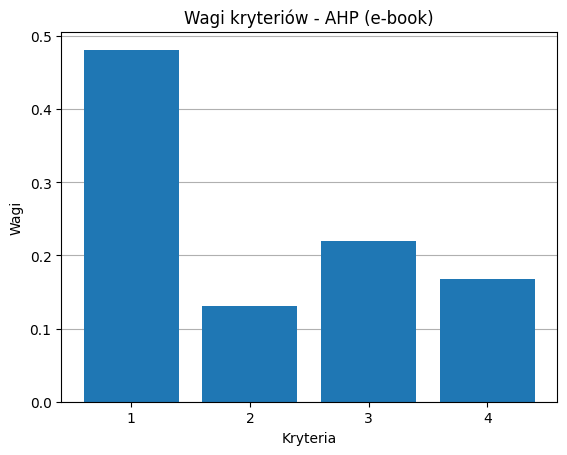

Wagi RANCOM : [0.4375 0.0625 0.3125 0.1875]
Spójność triad RANCOM: 1.0


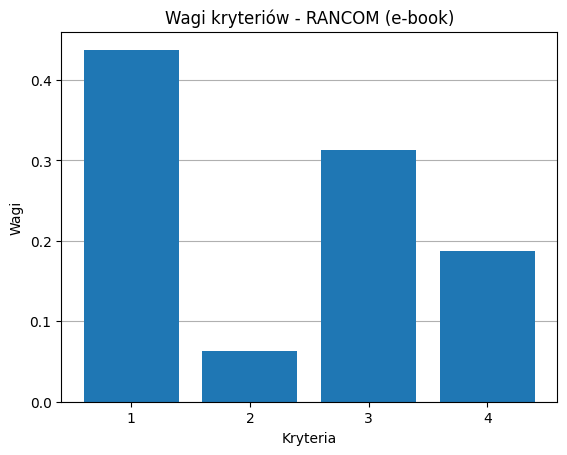

Problem 2 - telefon android
Wagi AHP: [0.41161678 0.09813516 0.18721634 0.1317089  0.09475591 0.07656691]
CR AHP: 0.014625073859934062


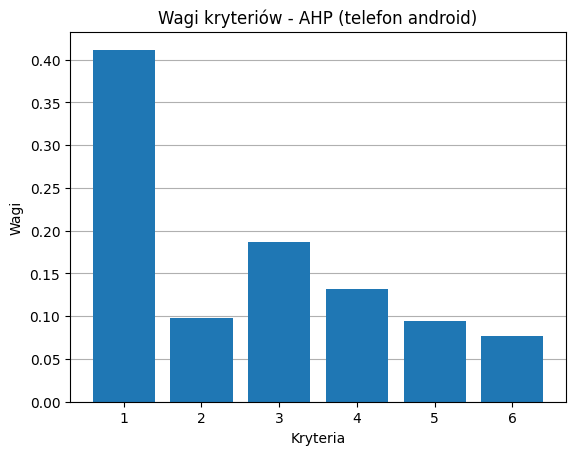

Wagi RANCOM : [0.30555556 0.13888889 0.25       0.19444444 0.08333333 0.02777778]
Spójność triad RANCOM: 1.0


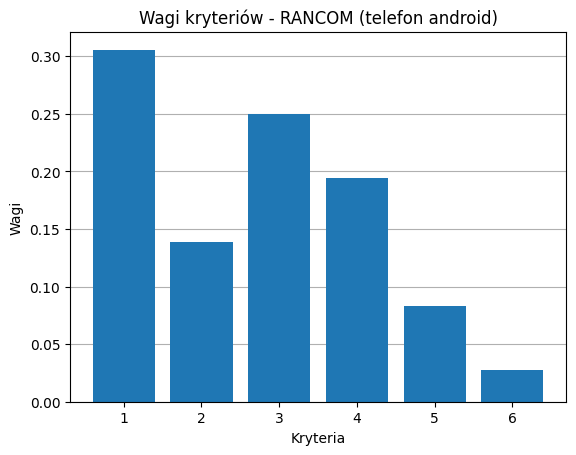

Problem 3 - laptop
Wagi AHP: [0.37296455 0.06365812 0.0625667  0.05478877 0.17094123 0.11459472
 0.08475591 0.07573   ]
CR AHP: 0.013950268046130847


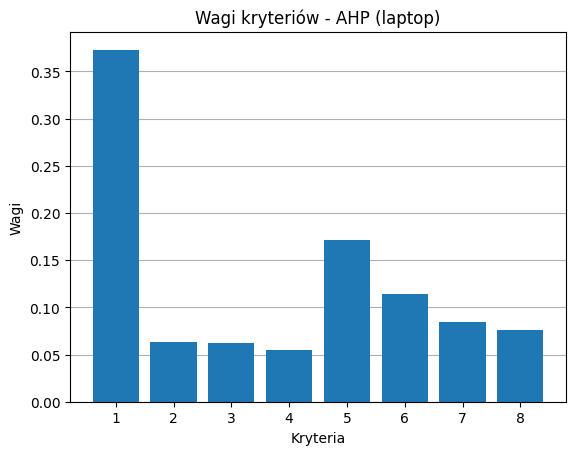

Wagi RANCOM : [0.234375 0.078125 0.046875 0.015625 0.203125 0.171875 0.140625 0.109375]
Spójność triad RANCOM: 1.0


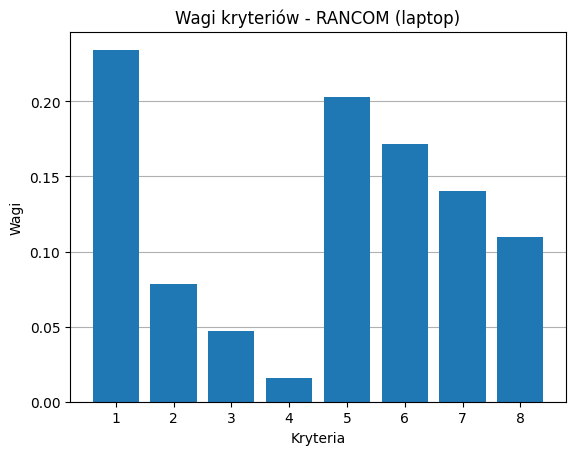

In [ ]:
for problem in range(1, 4):
    if problem == 1:
        name = "e-book"
        matrix = ebook_matrix
        types = ebook_types
        ranking = ebook_ranking
        print("Problem 1 - e-book")
    elif problem == 2:
        name = "telefon android"
        matrix = phone_matrix
        types = phone_types
        ranking = phone_ranking
        print("Problem 2 - telefon android")
    else:
        name = "laptop"
        matrix = laptop_matrix
        types = laptop_types
        ranking = laptop_ranking
        print("Problem 3 - laptop")

    for method in ["AHP", "RANCOM"]:
        if method == "AHP":
            ahp = AHP(ranking)
            weights_ahp = ahp()
            print("Wagi AHP:", weights_ahp)
            print("CR AHP:", ahp.get_cr())


            plt.bar(range(1, len(weights_ahp)+1), weights_ahp)
            plt.xlabel('Kryteria')
            plt.ylabel('Wagi')
            plt.title(f'Wagi kryteriów - AHP ({name})')
            plt.xticks(range(1, len(weights_ahp)+1))
            plt.grid(axis='y')
            plt.show()

        elif method == "RANCOM":
            rancom = RANCOM(ranking)
            weights_rancom = rancom()
            print("Wagi RANCOM :", weights_rancom)
            mac = rancom.matrix
            triads_cons = triads_consistency(mac)
            print("Spójność triad RANCOM:", triads_cons)

            plt.bar(range(1, len(weights_rancom)+1), weights_rancom)
            plt.xlabel('Kryteria')
            plt.ylabel('Wagi')
            plt.title(f'Wagi kryteriów - RANCOM ({name})')
            plt.xticks(range(1, len(weights_rancom)+1))
            plt.grid(axis='y')
            plt.show()

Dla wszystkich 3 problemów współczynnik CR dla AHP utrzymywał się na podobnym poziome. Triad_concistency dla RANCOM utrzymywał się na stale na tym sammym poziomie. Te 2 wnioski sugerują, ze dla obu metod macierze byłī spójne. W przedstawionych problemach nie zauwazono odstępstw, co sugeruje wysoką wiarygodność wyników i ewentualne rozszerzenie analiz, aby wykryć gdzie mógłby pojawić się limit, po którym zaczęłyby pojawiać się błedy itp. 